# 1.4 — How the curve moves

> *"Prices of futures contracts become more volatile as they approach maturity."* — Paul Samuelson, 1965.
> He proved it for a martingale; gas traders re-discover it every month.

## The problem

Chapter 1.3 pushed us toward hedging far-dated or illiquid exposures with the liquid front. That only
works if we know two things about the way the curve *moves*:

1. **How much** does each tenor move per day? (If M12 moves half as much as M1, a 1:1 hedge of M12 with
   M1 is a *double* hedge.)
2. **How together** do tenors move? (If the correlation is 0.7 rather than 1.0, part of the risk is not
   hedgeable with the front at all.)

Answering these turns the curve from a static picture into a *risk object*. This chapter uses a
simulated constant-maturity history whose properties mirror the stylised facts of gas curves; everything
we compute you can recompute on your own history with the same code.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.market_data import simulate_curve_history
from gashedge.plotting import plot_heatmap, plot_series
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch1.4")
log.info("Environment ready")

2026-09-13 16:46:54.734 | INFO    | ch1.4 | Environment ready


## 1. A constant-maturity history

Real contracts expire; a history of "the Dec-26 contract" is only a year or two long and gets *more*
volatile as it nears expiry. For statistics we therefore use **constant-maturity** series: M1 is always
"the front month", M2 always the second, and so on. On each roll date the identity of the underlying
contract changes — a subtlety that matters for stack-and-roll hedges (Chapter 2.4) but not for the
covariance structure we study here.

`simulate_curve_history` produces such a panel from a three-factor model
([Appendix C](../appendix/C_notation_pca_references.ipynb)):

$$
\Delta \ln P_i = \beta^{L}_i\, L_t + \beta^{S}_i\, S_t + \beta^{C}_i\, C_t + \epsilon_{i,t},
\qquad
\sigma_i = \sigma_{\infty} + (\sigma_1 - \sigma_{\infty})\, e^{-(i-1)/\lambda}
\tag{1.10}
$$

Level, slope and curvature shocks are common to all tenors; the idiosyncratic term $\epsilon$ is what
makes tenors imperfectly correlated; and the volatility $\sigma_i$ *decays with tenor* — the
**Samuelson effect**.

2026-09-13 16:46:54.741 | INFO    | gashedge.market_data | Simulated constant-maturity curve history: 750 days x 24 tenors


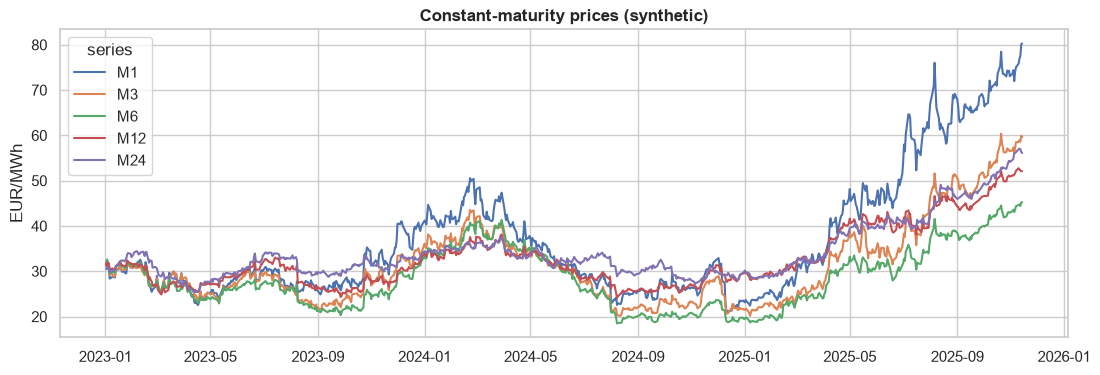

In [2]:
hist = simulate_curve_history(n_days=750, n_tenors=24)
dlog = np.log(hist).diff().dropna()
fig, ax = plt.subplots(figsize=(13, 4))
plot_series(hist[["M1", "M3", "M6", "M12", "M24"]], title="Constant-maturity prices (synthetic)", ax=ax);

## 2. Volatility term structure

Daily volatility of log-returns per tenor. Two conventions you will meet: **daily** $\sigma_d$ and
**annualised** $\sigma_a = \sigma_d\sqrt{252}$. Gas front-month annualised vol of 50–90 % in normal
times (and several hundred percent in 2022) is *not* a typo — it is one of the most volatile
liquid commodities in the world.

2026-09-13 16:46:54.886 | INFO    | ch1.4 | Front vol 55.1% vs M12 30.7% vs M24 24.0% (annualised)


,tenor,daily_vol,annualised_vol_pct
0,1,0.0347,55.1208
1,2,0.0320,50.7737
2,3,0.0303,48.0885
5,6,0.0252,39.9394
11,12,0.0194,30.7295
17,18,0.0165,26.1588
23,24,0.0151,23.9745


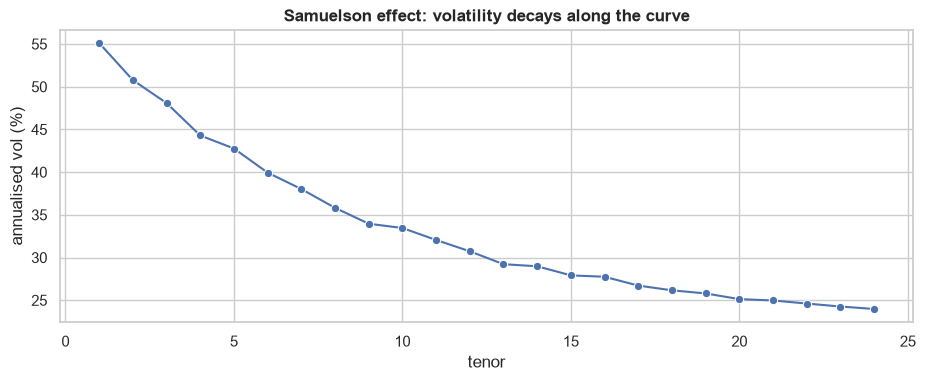

In [3]:
vol = pd.DataFrame({"tenor": np.arange(1, 25), "daily_vol": dlog.std().values})
vol["annualised_vol_pct"] = 100 * vol.daily_vol * np.sqrt(252)
fig, ax = plt.subplots(figsize=(11, 3.8))
sns.lineplot(data=vol, x="tenor", y="annualised_vol_pct", marker="o", ax=ax)
ax.set_title("Samuelson effect: volatility decays along the curve"); ax.set_ylabel("annualised vol (%)")
log.info("Front vol %.1f%% vs M12 %.1f%% vs M24 %.1f%% (annualised)", *vol.annualised_vol_pct.iloc[[0, 11, 23]])
vol.iloc[[0, 1, 2, 5, 11, 17, 23]].round(4)

**Why does this happen?** Near-term prices respond to *news that matters now*: a cold forecast, an LNG
tanker diverting, a Norwegian outage. Twelve months out, that news is mostly irrelevant — storage will
refill, the tanker will have come and gone. Only slow-moving information (long-term supply, policy) moves
the back. Less information flow per day → less variance per day.

## 3. The same MWh is not the same risk

Convert to euros. A 10,000 MWh position at price $P_i$ with daily vol $\sigma_i$ has a one-day P&L
standard deviation of

$$
\sigma_{\Pi,i} \;\approx\; Q \cdot P_i \cdot \sigma_i
\tag{1.11}
$$

Compare the front with the back:

2026-09-13 16:46:54.987 | INFO    | ch1.4 | 10k MWh in M1: 27877 EUR/day; in M12: 10085 EUR/day; ratio 2.76


,tenor,price,daily_vol,eur_std_1d_per_10k_mwh
0,1,80.283,0.035,27876.562
2,3,59.614,0.030,18058.796
5,6,45.238,0.025,11381.629
11,12,52.100,0.019,10085.383
23,24,56.089,0.015,8470.841


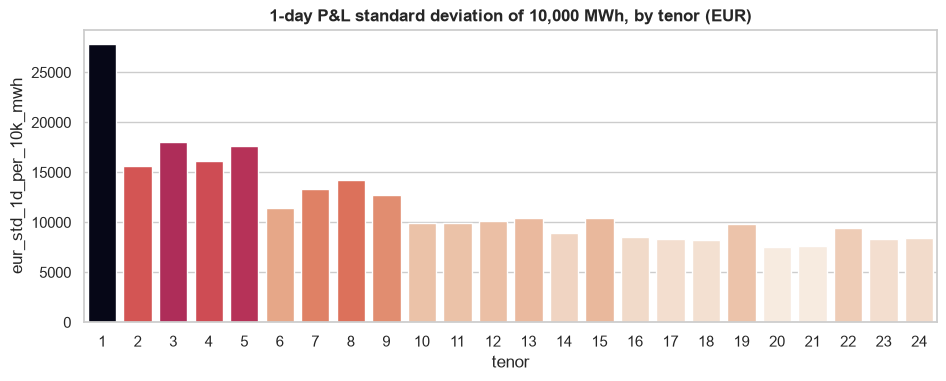

In [4]:
Q = 10_000
last = hist.iloc[-1]
risk = pd.DataFrame({"tenor": vol.tenor, "price": last.values, "daily_vol": vol.daily_vol})
risk["eur_std_1d_per_10k_mwh"] = Q * risk.price * risk.daily_vol
fig, ax = plt.subplots(figsize=(11, 3.8))
sns.barplot(data=risk, x="tenor", y="eur_std_1d_per_10k_mwh", hue="eur_std_1d_per_10k_mwh", palette="rocket_r", legend=False, ax=ax)
ax.set_title("1-day P&L standard deviation of 10,000 MWh, by tenor (EUR)")
log.info("10k MWh in M1: %.0f EUR/day; in M12: %.0f EUR/day; ratio %.2f", risk.eur_std_1d_per_10k_mwh.iloc[0],
         risk.eur_std_1d_per_10k_mwh.iloc[11], risk.eur_std_1d_per_10k_mwh.iloc[0] / risk.eur_std_1d_per_10k_mwh.iloc[11])
risk.iloc[[0, 2, 5, 11, 23]].round(3)

A hedger who neutralises **MWh** across the curve is *not* neutralising **risk**. Hedging 10,000 MWh of
M12 by selling 10,000 MWh of M1 replaces a small risk with a larger one of the opposite sign. We need a
*ratio* — and the ratio depends on volatility **and** correlation.

## 4. Correlation across tenors

The correlation matrix is the second half of the story. Adjacent tenors are highly correlated; the
front and the back much less so; and the pattern is smooth — which is what makes low-dimensional factor
models (level / slope / curvature) work so well for curves.

,M1,M2,M3,M6,M12,M24
M1,1.00,0.94,0.92,0.89,0.75,0.38
M2,0.94,1.00,0.94,0.92,0.80,0.44
M3,0.92,0.94,1.00,0.91,0.81,0.45
M6,0.89,0.92,0.91,1.00,0.89,0.55
M12,0.75,0.80,0.81,0.89,1.00,0.74
M24,0.38,0.44,0.45,0.55,0.74,1.00


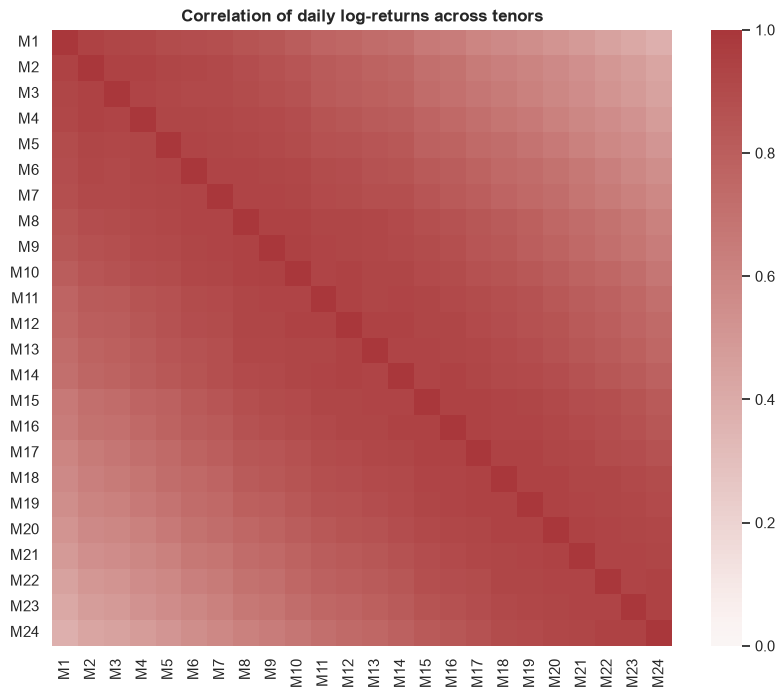

In [5]:
corr = dlog.corr()
fig, ax = plt.subplots(figsize=(10, 8))
plot_heatmap(corr, title="Correlation of daily log-returns across tenors", ax=ax, vmin=0, vmax=1, fmt=".2f")
sub = corr.loc[["M1", "M2", "M3", "M6", "M12", "M24"], ["M1", "M2", "M3", "M6", "M12", "M24"]].round(2)
sub

## 5. A first glimpse of the hedge ratio

Here is the key equation of Module 3, previewed without proof (the proof is Chapter 3.2 and
[Appendix A](../appendix/A_least_squares.ipynb)). To hedge an exposure $S$ with instrument $F$ so
that the *variance of the hedged P&L is minimised*, sell

$$
h^{*} \;=\; \frac{\text{Cov}(\Delta S, \Delta F)}{\text{Var}(\Delta F)} \;=\; \rho\,\frac{\sigma_S}{\sigma_F}
\tag{1.12}
$$

units of $F$ per unit of $S$. Two effects fight: the back moves *less* ($\sigma_S/\sigma_F < 1$) **and**
imperfectly ($\rho<1$), so the optimal amount of front-month to sell against a back-month exposure is
far below 1:1. Let us see how far.

In [6]:
d = hist.diff().dropna()                 # price changes in EUR/MWh (what P&L is made of)
rows = []
for t in (2, 3, 6, 12, 18, 24):
    s, f = d[f"M{t}"], d["M1"]
    rho = s.corr(f)
    h = s.cov(f) / f.var()
    eff_11 = 1 - (s - f).var() / s.var()
    eff_h = 1 - (s - h * f).var() / s.var()
    rows.append({"exposure": f"M{t}", "rho_with_M1": rho, "sigma_ratio": s.std() / f.std(), "h_star": h,
                 "var_reduction_1to1": eff_11, "var_reduction_hstar": eff_h})
preview = pd.DataFrame(rows)
log.info("Hedging M12 with M1: 1:1 removes %.0f%% of variance; h*=%.2f removes %.0f%%",
         100 * preview.loc[preview.exposure == "M12", "var_reduction_1to1"].iloc[0],
         preview.loc[preview.exposure == "M12", "h_star"].iloc[0],
         100 * preview.loc[preview.exposure == "M12", "var_reduction_hstar"].iloc[0])
preview.round(3)

2026-09-13 16:46:55.223 | INFO    | ch1.4 | Hedging M12 with M1: 1:1 removes -118% of variance; h*=0.36 removes 55%


,exposure,rho_with_M1,sigma_ratio,h_star,var_reduction_1to1,var_reduction_hstar
0,M2,0.918,0.707,0.649,0.596,0.842
1,M3,0.909,0.722,0.656,0.599,0.826
2,M6,0.875,0.547,0.479,-0.143,0.766
3,M12,0.742,0.486,0.361,-1.178,0.551
4,M18,0.565,0.443,0.250,-2.542,0.319
5,M24,0.359,0.397,0.143,-4.532,0.129


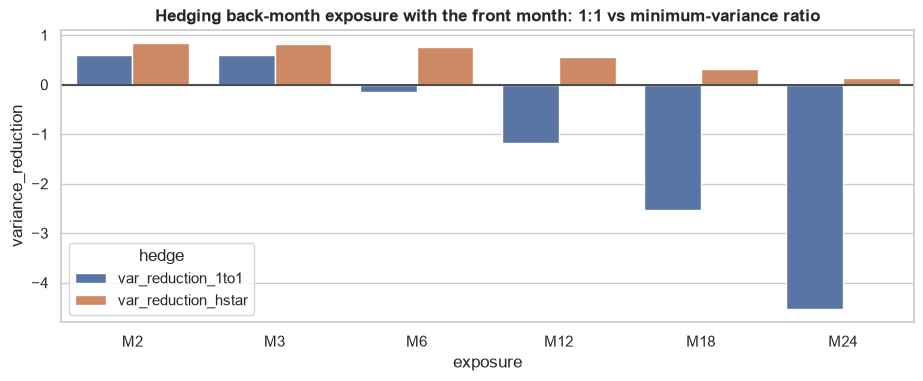

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.8))
long = preview.melt(id_vars="exposure", value_vars=["var_reduction_1to1", "var_reduction_hstar"], var_name="hedge", value_name="variance_reduction")
sns.barplot(data=long, x="exposure", y="variance_reduction", hue="hedge", ax=ax)
ax.axhline(0, color="0.3"); ax.set_title("Hedging back-month exposure with the front month: 1:1 vs minimum-variance ratio");

For the far tenors the 1:1 hedge can be **worse than no hedge at all** (negative variance reduction):
you have added a large front-month risk that is only loosely related to what you hold. The
minimum-variance ratio never does worse than nothing — by construction — but its ceiling is $\rho^2$,
and for M24 that ceiling is low. *Correlation, not volatility, is the binding constraint on proxy
hedging.*

## 6. Time-to-expiry and the roll: the constant-maturity blind spot

One more dynamic that constant-maturity series hide: a *specific* contract's volatility **rises** as it
approaches expiry (it "slides down" the Samuelson curve), and in its last days it can behave erratically
as physical players square up. A hedge in the front month therefore (a) gets riskier every day you hold
it, and (b) must be rolled before expiry (Chapter 1.1), paying the M1–M2 spread. These are costs of
*using* the liquid front that Chapter 2.4 puts numbers on.

## 7. Where this leaves us

The curve is a correlated, heteroskedastic bundle of tenors. Risk lives in **volatility × correlation**,
not in MWh. Any hedge that crosses tenors needs a ratio, and even the best ratio leaves residual
variance of $(1-\rho^2)$ of the original.

**Pitfall that leads to the next chapter:** we have only looked *along* the curve at one hub. Our risk
also crosses **hubs** (PEG vs TTF), where the same logic applies with a twist: the two hubs are linked by
physical pipelines and a *basis* that usually mean-reverts — until it does not. Chapter 1.5.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** Daily vol is 3.5 % for M1 and 1.5 % for M12; both trade at 35 EUR/MWh; their correlation is 0.70. What is the minimum-variance number of M1 MWh to sell against 10,000 MWh of M12, and what fraction of the variance does it remove? What happens with a 1:1 hedge?

<details><summary><i>Answer 1</i></summary>

By (1.12): $h^* = \rho\,\sigma_S/\sigma_F = 0.70 \times 1.5/3.5 = \mathbf{0.30}$ → sell **3,000 MWh** of M1. Variance removed $= \rho^2 = \mathbf{49\%}$. 1:1 hedge: hedged variance $= \sigma_S^2 + \sigma_F^2 - 2\rho\sigma_S\sigma_F = 1.5^2 + 3.5^2 - 2(0.7)(1.5)(3.5) = 2.25 + 12.25 - 7.35 = 7.15$ vs unhedged $2.25$ → variance **more than triples** (reduction of −218 %). The 1:1 hedge is far worse than doing nothing.

</details>

**Q2.** Give an economic reason (not a statistical one) why the Samuelson effect should be *stronger* in gas than in, say, gold futures.

<details><summary><i>Answer 2</i></summary>

Gold is storable at negligible cost with no seasonality, so a shock to today's price passes almost one-for-one into every future price (cost-of-carry links the curve rigidly) — little vol decay. Gas is expensive to store, storage capacity is finite, and demand is weather-driven; a shock to *today's* balance (cold snap, outage) can be absorbed by storage and LNG diversions before next winter, so it barely moves far tenors. The weaker the arbitrage link between prompt and forward, the steeper the Samuelson decay.

</details>

**Q3.** You hedge a Dec-27 exposure with the front month and intend to keep the hedge for 14 months. Name three distinct ways the *effective* hedge ratio drifts away from the one you computed today, using ideas from this chapter.

<details><summary><i>Answer 3</i></summary>

(i) **Samuelson drift of the exposure**: Dec-27 slides down the vol curve — its $\sigma_S$ rises each month, so $h^*$ must rise. (ii) **Roll**: every month your M1 becomes a different contract; the correlation of Dec-27 with the *new* M1 differs from the old, and you pay/earn the M1–M2 spread. (iii) **Correlation regime**: $\rho$ between front and back is not constant — it collapses in prompt-driven crises (2022) and rises in calm, well-supplied markets. A static ratio is wrong on all three counts; Chapter 3.5 covers re-estimation.

</details>

**Q4.** From the correlation matrix, adjacent tenors show ρ ≈ 0.9+ while M1–M24 shows a much lower value. Explain why this pattern makes a *three-factor* description of curve moves plausible, and what a hedge that neutralises only the first factor leaves behind.

<details><summary><i>Answer 4</i></summary>

Smoothly decaying correlation along the curve is exactly what a small number of *common* shocks with tenor-dependent loadings produce: a level shock (all tenors up), a slope shock (front up, back down), a curvature shock (middle vs ends). Adjacent tenors have almost identical loadings → ρ near 1; distant tenors differ in slope/curvature loadings → lower ρ. A hedge that only neutralises the level factor (e.g. matching total vol-weighted exposure with front-month futures) leaves the **slope and curvature** exposures — a calendar-spread position — plus idiosyncratic tenor noise. Chapter 3.3 quantifies this with PCA.

</details>


---
◀ [Previous](03_liquidity_profile.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](05_hubs_and_basis.ipynb)